# Marc vs. Mark - U.S. Male Births, 1880–2025

**Author:** Khaylub Thompson-Calvin

**Analytical question:** How did the popularity of two spellings of the same name - *Marc* and *Mark* - change over time in U.S. male births?

**Data:** U.S. Social Security Administration national baby-name totals (public domain). One file per year, `Name,Sex,Count`, no header.
Fetch it with `python scripts/download_ssa_data.py`; provenance for the copy used here is recorded in `data/raw/PROVENANCE.json`.

This notebook is the **reproducible** version of the analysis: it needs no database access, only the public SSA files.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 1. Locate the data

The notebook lives in `notebooks/`, so the data sits one level up. Both locations are checked so the
notebook works whether it is run from the repo root or from inside `notebooks/`.

In [2]:
candidates = [Path("../data/raw"), Path("data/raw")]
RAW = next((p for p in candidates if p.is_dir()), None)

if RAW is None:
    raise FileNotFoundError(
        "No data/raw directory found. Run: python scripts/download_ssa_data.py"
    )

year_files = sorted(RAW.glob("yob*.txt"))
print(f"Data directory: {RAW}")
print(f"Yearly files found: {len(year_files)}")

Data directory: ..\data\raw
Yearly files found: 146


## 2. Load and combine every year

Each file carries its year only in the filename, so the year is added as a column while loading.

In [3]:
frames = []
for path in year_files:
    year_data = pd.read_csv(path, header=None, names=["Name", "Sex", "Births"])
    year_data["Year"] = int(path.stem[3:])       # "yob1880" -> 1880
    frames.append(year_data)

all_names = pd.concat(frames, ignore_index=True)

print(f"Rows loaded: {len(all_names):,}")
print(f"Years covered: {all_names['Year'].min()}-{all_names['Year'].max()}")
all_names.head()

Rows loaded: 2,181,032
Years covered: 1880-2025


,Name,Sex,Births,Year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


## 3. Filter to the two names

Male births only, and only the two spellings under comparison.

In [4]:
selected = all_names[
    (all_names["Sex"] == "M") & (all_names["Name"].isin(["Marc", "Mark"]))
][["Year", "Name", "Births"]].sort_values("Year")

print(f"Rows after filtering: {len(selected)}")
print(f"Missing values: {selected.isna().sum().sum()}")
selected.head()

Rows after filtering: 263
Missing values: 0


,Year,Name,Births
1101,1880,Mark,85
3066,1881,Mark,94
5115,1882,Mark,90
7256,1883,Mark,91
9460,1884,Mark,96


## 4. Reshape long → wide

One row per year, one column per name - the shape a time-series plot wants.

In [5]:
births_by_year = selected.pivot(index="Year", columns="Name", values="Births")

print(f"Shape: {births_by_year.shape}")
print("\nMissing values per column:")
print(births_by_year.isna().sum())
births_by_year.head()

Shape: (146, 2)

Missing values per column:
Name
Marc    29
Mark     0
dtype: int64


Name,Marc,Mark
Year,,
1880,NaN,85.0
1881,NaN,94.0
1882,NaN,90.0
1883,NaN,91.0
1884,NaN,96.0


### A note on the missing values

`Marc` is absent from the earliest years. That is not a data error: SSA omits any name with **fewer than
5 occurrences** in a year, so a name simply does not appear until it clears that floor. The gap is
information - it tells us when the spelling entered measurable use.

In [6]:
first_marc = births_by_year["Marc"].first_valid_index()
first_mark = births_by_year["Mark"].first_valid_index()
missing_years = int(births_by_year["Marc"].isna().sum())

print(f"First year Mark appears: {first_mark}")
print(f"First year Marc appears: {first_marc}")
print(f"Years where Marc is below the reporting floor: {missing_years}")

First year Mark appears: 1880
First year Marc appears: 1901
Years where Marc is below the reporting floor: 29


## 5. Peak evidence

The headline numbers, computed rather than remembered.

In [7]:
summary = {}
for name in ["Mark", "Marc"]:
    series = births_by_year[name].dropna()
    summary[name] = {
        "peak_year": int(series.idxmax()),
        "peak_births": int(series.max()),
        "first_year": int(series.index.min()),
        "last_year": int(series.index.max()),
        "births_last_year": int(series.iloc[-1]),
    }

for name, stats in summary.items():
    print(f"{name}: peaked at {stats['peak_births']:,} births in {stats['peak_year']}"
          f"  (first seen {stats['first_year']}, {stats['births_last_year']:,} in {stats['last_year']})")

Mark: peaked at 58,727 births in 1960  (first seen 1880, 1,416 in 2025)
Marc: peaked at 5,009 births in 1970  (first seen 1901, 162 in 2025)


## 6. Compare the two trends

Three questions: did they peak at the same time, how big is the volume gap, and do the curves actually
move together?

In [8]:
peak_gap = summary["Marc"]["peak_year"] - summary["Mark"]["peak_year"]
peak_ratio = summary["Marc"]["peak_births"] / summary["Mark"]["peak_births"]

overlap = births_by_year.dropna()
pearson = overlap["Marc"].corr(overlap["Mark"])
spearman = overlap["Marc"].corr(overlap["Mark"], method="spearman")
ratio_by_year = overlap["Marc"] / overlap["Mark"]

print(f"Marc peaked {peak_gap} years after Mark")
print(f"Marc's peak was {peak_ratio:.1%} of Mark's peak (about 1 in {1/peak_ratio:.1f})")
print(f"\nOverlapping years: {overlap.index.min()}-{overlap.index.max()} ({len(overlap)} years)")
print(f"Correlation (Pearson):  {pearson:.3f}")
print(f"Correlation (Spearman): {spearman:.3f}")
print(f"\nMarc-to-Mark ratio across those years:"
      f" min {ratio_by_year.min():.3f}, median {ratio_by_year.median():.3f}, max {ratio_by_year.max():.3f}")

Marc peaked 10 years after Mark
Marc's peak was 8.5% of Mark's peak (about 1 in 11.7)

Overlapping years: 1901-2025 (117 years)
Correlation (Pearson):  0.797
Correlation (Spearman): 0.974

Marc-to-Mark ratio across those years: min 0.017, median 0.122, max 0.284


## 7. Visualize

Chart saved to ..\screenshots\names-trend-chart.png


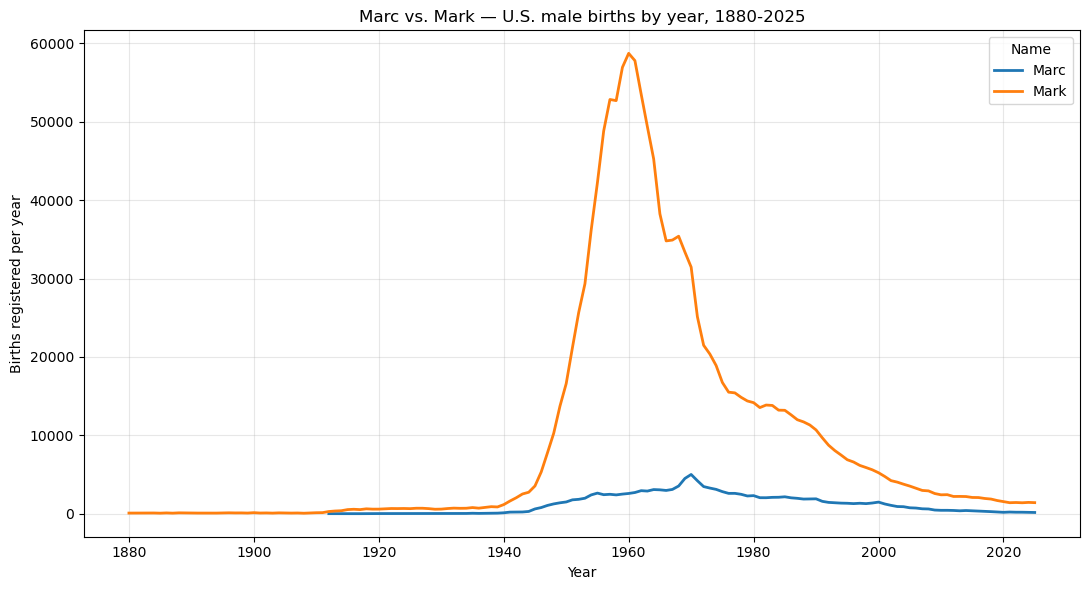

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

births_by_year.plot(ax=ax, linewidth=2)

ax.set_title("Marc vs. Mark - U.S. male births by year, 1880-2025")
ax.set_xlabel("Year")
ax.set_ylabel("Births registered per year")
ax.legend(title="Name")
ax.grid(alpha=0.3)

fig.tight_layout()

output_path = Path("../screenshots/names-trend-chart.png")
if not output_path.parent.is_dir():
    output_path = Path("screenshots/names-trend-chart.png")
fig.savefig(output_path, dpi=150)

print(f"Chart saved to {output_path}")
plt.show()

## 8. Interpretation

Both spellings follow the same broad arc: negligible before the 1940s, a sharp mid-century rise, a peak,
then a long decline that continues through 2025. They are clearly related trends - the rank correlation
across their 117 overlapping years is very high.

But "identical" would overstate it, in two specific ways:

1. **The peaks are ten years apart.** Mark peaks in **1960** at **58,727** births; Marc peaks in **1970**
   at **5,009**. Marc's rise and fall lag Mark's by roughly a decade.
2. **The volume gap is not constant.** At their respective peaks Marc reaches about **8.5%** of Mark's
   height, but the year-by-year ratio ranges from under 2% to about 28%. "Roughly a tenth" is a fair
   summary of the median (12%), not a stable relationship.

A cautious reading: *the two spellings rose and fell over broadly the same era, with Marc consistently far
less common and its trajectory shifted about a decade later.* Nothing here explains **why** either name
moved - the data shows the pattern, not its cause.

## 9. Limitations

- SSA omits names with **fewer than 5 occurrences** in a year, so early Marc history is truncated rather
  than absent.
- Counts come from Social Security card applications, not a complete birth registry.
- This compares two spellings of one name; it says nothing about naming trends generally.
- Correlation between two time series that both rise and fall mid-century is partly a shared-era effect,
  not evidence that one influenced the other.